In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
tb = IRSwapsTB(mdp=mdp)

In [6]:
# q = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": 1})
q = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.FLY, structure_kwargs={"front_tenor": "1Yx2Y", "belly_tenor": "1Yx5Y", "back_tenor": "1Yx10Y", "bpv": 1})
df = tb.get_timeseries(start=datetime.date(2025, 1, 1), end=datetime.date(2025, 9, 29), queries=[q], n_jobs=1)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 166/166 [00:04<00:00, 41.47it/s]


,USD-SOFR-1D 1Yx2Y-5Y-10Y FLY RATE
Date,
2025-01-02,-2.896941
2025-01-03,-3.271583
2025-01-06,-1.975624
2025-01-07,-0.634318
2025-01-08,-0.011806
...,...
2025-09-23,-11.760034
2025-09-24,-11.094613
2025-09-25,-10.551641


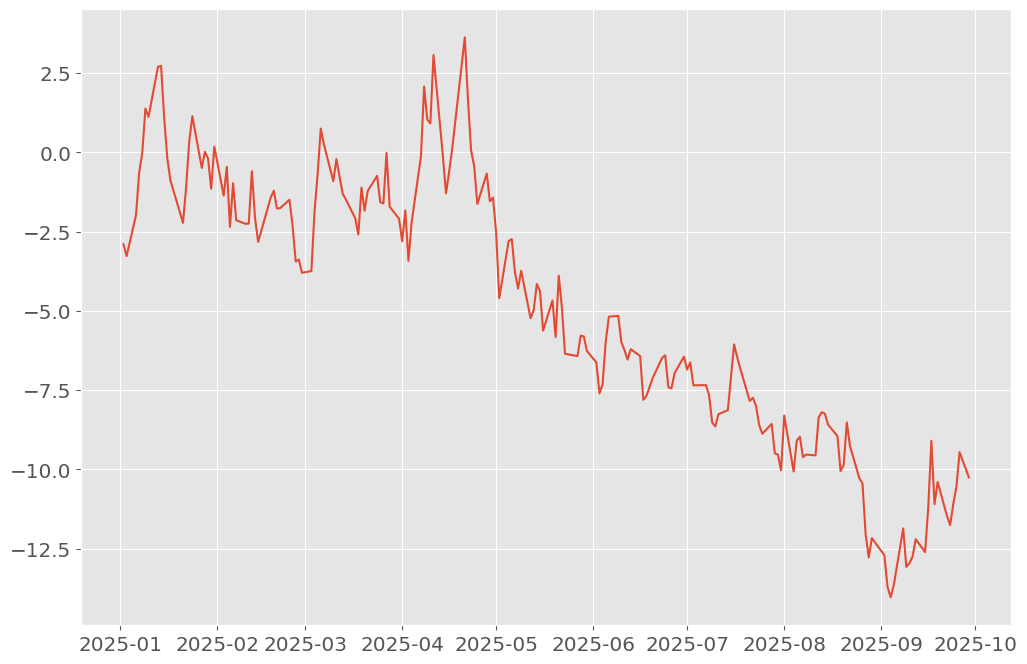

In [7]:
plt.plot(df.index, df[q.col_name()])